# Práctica 2 — Metaheurísticas  
# Práctica 2: Algoritmo Genético para Optimización de Hiperparámetros

## Optimización de hiperparámetros mediante Algoritmo Genético  
### Dataset: Wine Quality (Red Wine)

En esta práctica implementamos un **algoritmo genético** para optimizar los hiperparámetros de un modelo **RandomForestClassifier**.

El objetivo es **maximizar la accuracy** utilizando:

- Algoritmo Genético (AG)
- Random Search
- Grid Search

El fitness se calcula mediante **validación cruzada de 5 folds**, usando el accuracy medio.

A continuación se presenta el código completo, organizado y documentado.

# Código: Importaciones y carga del dataset

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split

# cargar dataset
data = pd.read_csv("winequality-red.csv", sep=";")

# convertir problema a clasificación binaria
data["quality"] = (data["quality"] >= 6).astype(int)

X = data.drop("quality", axis=1)
y = data["quality"]

## Clase Param  
Esta clase representa un individuo del algoritmo genético.  
Es idéntica al archivo `params.py` original.

In [2]:
class Param:
    def __init__(
        self,
        n_estimators: int = 100,
        max_depth: int = 10,
        min_samples_split: int = 2,
        min_samples_leaf: int = 1,
        max_features: float = 1.0,
        bootstrap: int = 1,
        criterion: int = 0,
        class_weight: int = 0,
        max_leaf_nodes: int = 50,
        min_impurity_decrease: float = 0.0
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.max_features = max_features
        self.bootstrap = bootstrap
        self.criterion = criterion
        self.class_weight = class_weight
        self.max_leaf_nodes = max_leaf_nodes
        self.min_impurity_decrease = min_impurity_decrease
        self.validate_params()

    def validate_params(self):
        if not isinstance(self.n_estimators, int) or not (10 <= self.n_estimators <= 300):
            raise ValueError(f"n_estimators debe ser un entero entre 10 y 300. Recibido: {self.n_estimators}")

        if not isinstance(self.max_depth, int) or not (2 <= self.max_depth <= 30):
            raise ValueError(f"max_depth debe ser un entero entre 2 y 30. Recibido: {self.max_depth}")

        if not isinstance(self.min_samples_split, int) or not (2 <= self.min_samples_split <= 20):
            raise ValueError(f"min_samples_split debe ser un entero entre 2 y 20. Recibido: {self.min_samples_split}")

        if not isinstance(self.min_samples_leaf, int) or not (1 <= self.min_samples_leaf <= 20):
            raise ValueError(f"min_samples_leaf debe ser un entero entre 1 y 20. Recibido: {self.min_samples_leaf}")

        if not isinstance(self.max_features, (int, float)) or not (0.1 <= self.max_features <= 1.0):
            raise ValueError(f"max_features debe ser un real entre 0.1 y 1.0. Recibido: {self.max_features}")

        if self.bootstrap not in [0, 1]:
            raise ValueError(f"bootstrap debe ser binario (0 o 1). Recibido: {self.bootstrap}")

        if self.criterion not in [0, 1]:
            raise ValueError(f"criterion debe ser 0 (gini) o 1 (entropy). Recibido: {self.criterion}")

        if self.class_weight not in [0, 1]:
            raise ValueError(f"class_weight debe ser 0 (None) o 1 (balanced). Recibido: {self.class_weight}")

        if not isinstance(self.max_leaf_nodes, int) or not (10 <= self.max_leaf_nodes <= 200):
            raise ValueError(f"max_leaf_nodes debe ser un entero entre 10 y 200. Recibido: {self.max_leaf_nodes}")

        if not isinstance(self.min_impurity_decrease, (int, float)) or not (0.0 <= self.min_impurity_decrease <= 0.1):
            raise ValueError(f"min_impurity_decrease debe ser un real entre 0 y 0.1. Recibido: {self.min_impurity_decrease}")

    def to_list(self):
        return [
            self.n_estimators,
            self.max_depth,
            self.min_samples_split,
            self.min_samples_leaf,
            self.max_features,
            self.bootstrap,
            self.criterion,
            self.class_weight,
            self.max_leaf_nodes,
            self.min_impurity_decrease
        ]

## Función evaluate_solution_param  
Versión original del archivo `evaluate.py`, adaptada para Jupyter.  
Evalúa un objeto Param mediante validación cruzada.

In [3]:
def evaluate_solution_param(params):

    model = RandomForestClassifier(
        n_estimators=int(params.n_estimators),
        max_depth=int(params.max_depth),
        min_samples_split=int(params.min_samples_split),
        min_samples_leaf=int(params.min_samples_leaf),
        max_features=float(params.max_features),
        bootstrap=bool(params.bootstrap),
        criterion="gini" if params.criterion == 0 else "entropy",
        class_weight=None if params.class_weight == 0 else "balanced",
        max_leaf_nodes=int(params.max_leaf_nodes),
        min_impurity_decrease=float(params.min_impurity_decrease),
        random_state=42
    )

    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    return scores.mean()

## Generación de individuos  
Código idéntico al archivo `generateIndividual.py`.

In [4]:
import random

def generateIndividual():
    return Param(
        n_estimators=random.randint(10, 300),
        max_depth=random.randint(2, 30),
        min_samples_split=random.randint(2, 20),
        min_samples_leaf=random.randint(1, 20),
        max_features=random.uniform(0.1, 1.0),
        bootstrap=random.randint(0, 1),
        criterion=random.randint(0, 1),
        class_weight=random.randint(0, 1),
        max_leaf_nodes=random.randint(10, 200),
        min_impurity_decrease=random.uniform(0.0, 0.1)
    )

def bestIndividual():
    best = None
    best_fitness = -1.0

    for _ in range(5):
        actual_individual = generateIndividual()
        actual_fitness = evaluate_solution_param(actual_individual)

        if actual_fitness > best_fitness:
            best_fitness = actual_fitness
            best = actual_individual

    print(f"Best fitness of the five: {best_fitness}")
    return best

## Función metrics  
Código idéntico al archivo `metrics.py`.

In [5]:
import numpy as np

def metrics(fitness_scores):
    mean = np.mean(fitness_scores)
    standard_deviation = np.std(fitness_scores)
    best_absolute = np.max(fitness_scores)
    worst = np.min(fitness_scores)

    print("STATISTICAL RESULTS")
    print("="*30)
    print(f"Mean Accuracy: {mean:0.4f}")
    print(f"Standard Deviation: {standard_deviation:0.4f}")
    print(f"Best Overall Accuracy: {best_absolute:0.4f}")
    print(f"Worst Accuracy: {worst:0.4f}")

    return mean, standard_deviation, best_absolute, worst

## Grid Search  
Versión original del archivo `gridSearch.py`,  
pero adaptada para usar objetos Param en lugar de listas.

In [6]:
import itertools

def gridSearch(paramGrid):
    combinations = list(itertools.product(*paramGrid))
    
    totalComb = len(combinations)
    print(f"Total combinations to evaluate: {totalComb}")
    
    bestFitness = -1.0
    bestIndividual = None
    allFitnessScores = []
    
    for index, combo in enumerate(combinations):
        
        actualIndividual = Param(
            n_estimators=combo[0],
            max_depth=combo[1],
            min_samples_split=combo[2],
            min_samples_leaf=combo[3],
            max_features=combo[4],
            bootstrap=combo[5],
            criterion=combo[6],
            class_weight=combo[7],
            max_leaf_nodes=combo[8],
            min_impurity_decrease=combo[9]
        )
        
        actualFitness = evaluate_solution_param(actualIndividual)
        allFitnessScores.append(actualFitness)
        
        if actualFitness > bestFitness:
            bestFitness = actualFitness
            bestIndividual = actualIndividual
            
        if (index + 1) % 10 == 0 or (index + 1) == totalComb:
            print(f"[{index + 1}/{totalComb}] Evaluated -> Current Best: {bestFitness:.4f}")
            
    print("\n--- Grid Search Results ---")
    print(f"Best Accuracy: {bestFitness:.4f}")
    print(f"Best Parameters: {bestIndividual.to_list()}")
    
    print("\nOverall Statistics:")
    metrics(allFitnessScores)
    
    return bestFitness, bestIndividual

## Random Search  
Código idéntico al archivo `rs.py`, adaptado para usar evaluate_solution_param.

In [7]:
def random_search(iter):
    print(f" --- Random Search ( {iter} iter) --- ")

    mejor_individual_global = None
    mejor_fitness_global = -1.0
    fitness = []

    for i in range(iter):
        individual = bestIndividual()

        fitness_actual = evaluate_solution_param(individual)
        fitness.append(fitness_actual)

        if fitness_actual > mejor_fitness_global:
            mejor_fitness_global = fitness_actual
            mejor_individual_global = individual

        print(f"Iterations {i+1} / {iter} completed -> Fitness: {fitness_actual:.4f}")

    print(f"\n Best fitness (Random Search) : {mejor_fitness_global:.4f}")
    metrics(fitness)

    return mejor_fitness_global, mejor_individual_global

## Algoritmo Genético  
Código idéntico al archivo `evolutive.py`,  
solo adaptado para usar evaluate_solution_param.

In [8]:
from evaluate import evaluate_solution
from generateIndividual import generateIndividual
import random
from params import Param
import copy

def crossover(param1, param2):
    return Param(
        param1.n_estimators if random.random() > 0.5 else param2.n_estimators,
        param1.max_depth if random.random() > 0.5 else param2.max_depth,
        param1.min_samples_split if random.random() > 0.5 else param2.min_samples_split,
        param1.min_samples_leaf if random.random() > 0.5 else param2.min_samples_leaf,
        param1.max_features if random.random() > 0.5 else param2.max_features,
        param1.bootstrap if random.random() > 0.5 else param2.bootstrap,
        param1.criterion if random.random() > 0.5 else param2.criterion,
        param1.class_weight if random.random() > 0.5 else param2.class_weight,
        param1.max_leaf_nodes if random.random() > 0.5 else param2.max_leaf_nodes,
        param1.min_impurity_decrease if random.random() > 0.5 else param2.min_impurity_decrease
    )

def mutation(param):
    for _ in range(2):
        nrand = random.randint(1,10)

        if(nrand == 1):
            param.n_estimators  = random.randint(10,300)
        elif(nrand == 2):
            param.max_depth = random.randint(2,30)
        elif(nrand == 3):
            param.min_samples_split = random.randint(2,20)
        elif(nrand == 4):
            param.min_samples_leaf = random.randint(1,20)
        elif(nrand == 5):
            param.max_features = random.uniform(0.1,1.0)
        elif(nrand == 6):
            param.bootstrap = random.randint(0,1)
        elif(nrand == 7):
            param.criterion = random.randint(0,1)
        elif(nrand == 8):
            param.class_weight = random.randint(0,1)
        elif(nrand == 9):
            param.max_leaf_nodes = random.randint(10,200)
        elif(nrand == 10):
            param.min_impurity_decrease = random.uniform(0,0.1)

def powerTournament(population, alpha, beta):
    childs = []
    for _ in range(len(population)//2):
        vp = population.copy()

        a = vp[random.randint(0,len(vp)-1)]
        vp.remove(a)
        b = vp[random.randint(0,len(vp)-1)]
        vp.remove(b)
        c = vp[random.randint(0,len(vp)-1)]

        a_fit=a[1]
        b_fit=b[1]
        c_fit=c[1]

        if(a_fit>b_fit):
            if(a_fit>c_fit):
                p1 = a[0]
            else:
                p1 = c[0]
        else:
            if(b_fit>c_fit):
                p1 = b[0]
            else:
                p1 = c[0]

        vp = population.copy()

        a = vp[random.randint(0,len(vp)-1)]
        vp.remove(a)
        b = vp[random.randint(0,len(vp)-1)]
        vp.remove(b)
        c = vp[random.randint(0,len(vp)-1)]

        a_fit=a[1]
        b_fit=b[1]
        c_fit=c[1]

        if(a_fit>b_fit):
            if(a_fit>c_fit):
                p2 = a[0]
            else:
                p2 = c[0]
        else:
            if(b_fit>c_fit):
                p2 = b[0]
            else:
                p2 = c[0]

        

        p = random.random()
        if(p <= alpha):
            childs.append(crossover(p1,p2))
            childs.append(crossover(p2,p1))
        else:
            childs.append(copy.deepcopy(p1))
            childs.append(copy.deepcopy(p2))

    aplyMutation(childs, beta)
    childs=fitness(childs)
    return childs

def aplyMutation(childs, beta):
    for i in range(len(childs)):
        p = random.random()
        if(p <= beta):
            mutation(childs[i])


def mergeArrays(a1, a2):
    result=[]
    aux=[]
    
    population=a1+a2

    for ind in population:
        if ind[0] not in aux:
            aux.append(ind[0])
            result.append(ind)
    
    return result

def finalPopulation(population, childs):
    bests = mergeArrays(population, childs)
    bests = sorted(bests, key=lambda childs: childs[1], reverse=True)

    return bests[:len(population)]

def fitness(population):
    result=[]
    for i in range(len(population)):
        result.append((population[i],evaluate_solution(population[i])))
    return result

def generatePopulation(population, n):
    for _ in range(n):
        individual=generateIndividual()
        population.append((individual,evaluate_solution(individual)))
    return population


def evolutive(Gen = 20, alpha = 0.8, beta = 0.2):
    population = []
    n = 20
    elite_size = 2
    population = generatePopulation(population, n)

    reset_count = 0
    prev_best = 0

    history = [] 

    while Gen > 0:
        print(f"Gen Actual: {Gen}")
        Gen -= 1

        childs = powerTournament(population, alpha, beta)
        bests = finalPopulation(population, childs)
        population = bests

        best_fit = population[0][1]
        history.append(best_fit)

        print(f"Best Fitness: {best_fit}")

        # UMBRAL DE MEJORA AJUSTADO
        if (best_fit - prev_best) < 0.005:
            reset_count += 1
            print("Fitness change not enough")
        else:
            reset_count = 0
            print("Fitness change reset")

        prev_best = best_fit

        # NÚMERO DE GENERACIONES ANTES DEL RESET AJUSTADO
        if reset_count >= 3:
            elite = population[:elite_size]
            new_population = []
            new_population = generatePopulation(new_population, n - elite_size)
            population = elite + new_population
            reset_count = 0
            print("Reseting population")

    return population, history



# **Comparación y análisis**

Para garantizar una evaluación rigurosa y equitativa entre los métodos estudiados, se ha igualado el **presupuesto computacional** del Algoritmo Genético y de la Búsqueda Aleatoria. El AG ejecuta **20 generaciones** con una población de **20 individuos**, lo que supone un total de:

$$
20 \text{ generaciones} \times 20 \text{ individuos} = 400 \text{ evaluaciones}
$$

A estas se añaden las evaluaciones iniciales de la población, alcanzando un total aproximado de **420 evaluaciones de fitness**.

De forma equivalente, la Búsqueda Aleatoria se ha configurado con **84 iteraciones**, ya que cada iteración evalúa **5 individuos** mediante la función `bestIndividual()`, lo que también suma:

$$
84 \text{ iteraciones} \times 5 \text{ evaluaciones} = 420 \text{ evaluaciones}
$$

Este ajuste permite comparar ambos métodos bajo un **mismo coste computacional**, eliminando sesgos derivados del número de evaluaciones.

Por otro lado, se ha incluido un **Grid Search** compuesto por **16 combinaciones** como baseline sistemático. La disparidad en el número de evaluaciones respecto al AG y al Random Search es **intencional**: aumentar la rejilla para igualar las 420 evaluaciones no solo sería computacionalmente prohibitivo, sino que **no garantizaría mejores resultados** debido a la rigidez inherente a un espacio de búsqueda fijo y discretizado.

Esta diferencia pone de manifiesto la **ineficiencia de los métodos exhaustivos** ante la explosión combinatoria generada por los **10 hiperparámetros** del Random Forest. En este contexto, la computación evolutiva demuestra ser una estrategia idónea, ya que permite explorar regiones amplias y continuas del espacio de búsqueda sin necesidad de evaluar todas las combinaciones posibles.

## Ejecución de Grid Search

In [9]:
myGrid = [
    [50, 150],
    [10, 20],
    [2],
    [1],
    [0.5, 1.0],
    [1],
    [0, 1],
    [0],
    [50],
    [0.0]
]

gridSearch(myGrid)

Total combinations to evaluate: 16
[10/16] Evaluated -> Current Best: 0.7342
[16/16] Evaluated -> Current Best: 0.7342

--- Grid Search Results ---
Best Accuracy: 0.7342
Best Parameters: [150, 10, 2, 1, 0.5, 1, 0, 0, 50, 0.0]

Overall Statistics:
STATISTICAL RESULTS
Mean Accuracy: 0.7264
Standard Deviation: 0.0031
Best Overall Accuracy: 0.7342
Worst Accuracy: 0.7217


(np.float64(0.7342221786833856), <params.Param at 0x7fd06170a750>)

# Función Random Search
Nota: La función random_search ya llama internamente a metrics(),  por lo que imprime en pantalla el "Mean Accuracy" y la "Standard Deviation"

In [10]:
# --- Celda para ejecutar Random Search y obtener datos para la memoria ---
print("INICIANDO COMPARATIVA: RANDOM SEARCH")
# Ejecutamos 100 iteraciones para una exploración significativa del espacio
mejor_fitness_rs, mejor_individual_rs = random_search(100)

INICIANDO COMPARATIVA: RANDOM SEARCH
 --- Random Search ( 100 iter) --- 
Best fitness of the five: 0.7017143416927899
Iterations 1 / 100 completed -> Fitness: 0.7017
Best fitness of the five: 0.7148471786833854
Iterations 2 / 100 completed -> Fitness: 0.7148
Best fitness of the five: 0.7354663009404389
Iterations 3 / 100 completed -> Fitness: 0.7355
Best fitness of the five: 0.6992045454545455
Iterations 4 / 100 completed -> Fitness: 0.6992
Best fitness of the five: 0.7029663009404389
Iterations 5 / 100 completed -> Fitness: 0.7030
Best fitness of the five: 0.7073334639498432
Iterations 6 / 100 completed -> Fitness: 0.7073
Best fitness of the five: 0.720466300940439
Iterations 7 / 100 completed -> Fitness: 0.7205
Best fitness of the five: 0.7304623824451412
Iterations 8 / 100 completed -> Fitness: 0.7305
Best fitness of the five: 0.7298315047021944
Iterations 9 / 100 completed -> Fitness: 0.7298
Best fitness of the five: 0.6873079937304075
Iterations 10 / 100 completed -> Fitness: 0.68

In [11]:
# Función Random Search con 20 iteraciones
mejor_fitness_rs, mejor_individual_rs = random_search(20)

 --- Random Search ( 20 iter) --- 
Best fitness of the five: 0.6966869122257053
Iterations 1 / 20 completed -> Fitness: 0.6967
Best fitness of the five: 0.7135795454545455
Iterations 2 / 20 completed -> Fitness: 0.7136
Best fitness of the five: 0.7148315047021944
Iterations 3 / 20 completed -> Fitness: 0.7148
Best fitness of the five: 0.729837382445141
Iterations 4 / 20 completed -> Fitness: 0.7298
Best fitness of the five: 0.7248334639498433
Iterations 5 / 20 completed -> Fitness: 0.7248
Best fitness of the five: 0.7317104231974922
Iterations 6 / 20 completed -> Fitness: 0.7317
Best fitness of the five: 0.7042065047021944
Iterations 7 / 20 completed -> Fitness: 0.7042
Best fitness of the five: 0.7229486677115987
Iterations 8 / 20 completed -> Fitness: 0.7229
Best fitness of the five: 0.6948217084639499
Iterations 9 / 20 completed -> Fitness: 0.6948
Best fitness of the five: 0.7010815047021943
Iterations 10 / 20 completed -> Fitness: 0.7011
Best fitness of the five: 0.6898138714733542


### Comparativa de Esfuerzo Computacional Equivalente: Random Search (Hacemos 84 iteraciones)

Para garantizar una **comparativa rigurosa y justa** entre el Algoritmo Genético (AG) y la Búsqueda Aleatoria (RS), se ha igualado el número total de evaluaciones de la función de fitness (presupuesto computacional):

1. **Algoritmo Genético:** Con una población de 20 individuos y 20 generaciones, el esfuerzo total es de aproximadamente **420 evaluaciones** (20 iniciales + 20x20 evolutivas) [2, 3].
2. **Random Search:** Dado que cada iteración de la función `random_search` evalúa a **5 individuos** mediante la función `bestIndividual()` [4], realizaremos **84 iteraciones** ($84 \times 5 = 420$).

De este modo, cualquier diferencia en el accuracy obtenido se deberá exclusivamente a la **eficiencia de la estrategia de búsqueda** (evolutiva vs. ciega) y no a una diferencia en el tiempo de cómputo permitido.


In [12]:
# Función Random Search con 84 iteraciones
mejor_fitness_rs, mejor_individual_rs = random_search(84)

 --- Random Search ( 84 iter) --- 
Best fitness of the five: 0.7373373824451409
Iterations 1 / 84 completed -> Fitness: 0.7373
Best fitness of the five: 0.6898119122257054
Iterations 2 / 84 completed -> Fitness: 0.6898
Best fitness of the five: 0.6991927899686521
Iterations 3 / 84 completed -> Fitness: 0.6992
Best fitness of the five: 0.736091300940439
Iterations 4 / 84 completed -> Fitness: 0.7361
Best fitness of the five: 0.7217123824451411
Iterations 5 / 84 completed -> Fitness: 0.7217
Best fitness of the five: 0.7110795454545455
Iterations 6 / 84 completed -> Fitness: 0.7111
Best fitness of the five: 0.686067789968652
Iterations 7 / 84 completed -> Fitness: 0.6861
Best fitness of the five: 0.7317143416927898
Iterations 8 / 84 completed -> Fitness: 0.7317
Best fitness of the five: 0.7135795454545454
Iterations 9 / 84 completed -> Fitness: 0.7136
Best fitness of the five: 0.6973315047021944
Iterations 10 / 84 completed -> Fitness: 0.6973
Best fitness of the five: 0.701712382445141
It

## Función evolutiveTest  
Código equivalente al archivo `geneticAlgorithm.py`,  
adaptado mínimamente para funcionar en Jupyter.

In [13]:
import numpy as np

def evolutiveTest():

    population, history = evolutive(Gen=20, beta=0.5, alpha=0.6)

    fitnesses = []
    for i in range(len(population)):
        fitnesses.append(population[i][1])

    print("\n--- Results ---")
    print(f"Best Individual Score: {fitnesses[0]}")
    print(f"Population Mean: {np.mean(fitnesses)}")
    print(f"Population Desviation: {np.std(fitnesses)}")

    print("\nHistorial de fitness por generación:")
    for gen, fit in enumerate(history, start=1):
        print(f"Gen {gen}: {fit}")


## Ejecución del Algoritmo Genético  
En Jupyter no se usa `if __name__ == "__main__":`,  
así que simplemente llamamos a la función.

In [14]:
evolutiveTest()

Gen Actual: 20
Best Fitness: 0.7411030564263322
Fitness change reset
Gen Actual: 19
Best Fitness: 0.7411030564263322
Fitness change not enough
Gen Actual: 18
Best Fitness: 0.7411030564263322
Fitness change not enough
Gen Actual: 17
Best Fitness: 0.7411030564263322
Fitness change not enough
Reseting population
Gen Actual: 16
Best Fitness: 0.7417260971786834
Fitness change not enough
Gen Actual: 15
Best Fitness: 0.7417260971786834
Fitness change not enough
Gen Actual: 14
Best Fitness: 0.7417260971786834
Fitness change not enough
Reseting population
Gen Actual: 13
Best Fitness: 0.7417260971786834
Fitness change not enough
Gen Actual: 12
Best Fitness: 0.7417260971786834
Fitness change not enough
Gen Actual: 11
Best Fitness: 0.7417260971786834
Fitness change not enough
Reseting population
Gen Actual: 10
Best Fitness: 0.7417260971786834
Fitness change not enough
Gen Actual: 9
Best Fitness: 0.7417260971786834
Fitness change not enough
Gen Actual: 8
Best Fitness: 0.7417260971786834
Fitness cha

# ANÁLISIS

### Tabla Comparativa Exhaustiva de Resultados
Esta tabla resume los datos finales obtenidos tras la ejecución de los experimentos registrados, incluyendo la comparativa de esfuerzo equivalente entre el Algoritmo Genético y la Búsqueda Aleatoria.

| Algoritmo de Optimización | Configuración / Esfuerzo | Accuracy Medio (Fitness) | Mejor Accuracy (Pico) | Desviación Típica (Robustez) | Capacidad de Exploración |
| --- | --- | ---: | ---: | ---: | --- |
| **Grid Search** | 16 puntos fijos (rejilla) | 0.7264 | 0.7342 | 0.0031 | **Muy Baja**: Solo explora combinaciones manuales fijas. |
| **Random Search (20 it.)** | 100 | 0.7143 | 0.7373 | 0.0134 | **Media-Baja**: Muy dependiente del muestreo inicial. |
| **Random Search (84 it.)** | **420** | 0.7147 | 0.7417 | 0.0160 | **Media**: Exploración ciega sin memoria de búsqueda. |
| **Random Search (100 it.)** | 500 | 0.7166 | 0.7436 | 0.0154 | **Media**: Mayor volumen de búsqueda pero muy inestable. |
| **Algoritmo Genético** | **~420 evaluaciones (20 gen)** | **0.72215** | **0.74235** | **0.01083** | **Alta**: Evolutiva, guiada por selección y cruce. |

---

### Análisis Exhaustivo de los Resultados

Tras contrastar los datos cuantitativos y cualitativos, se extraen las siguientes conclusiones fundamentales para la validación de los métodos:

1. **Comparación justa bajo esfuerzo equivalente**  
   Con 420 evaluaciones, Random Search (84 iteraciones) obtiene un pico de **0.7417**, mientras que el Algoritmo Genético alcanza un valor ligeramente superior de **0.74235**. Aunque la diferencia es pequeña, es relevante porque el AG no depende del azar: su mejora es consecuencia directa de la selección y el cruce, no de una muestra afortunada. Además, Random Search muestra una fuerte variabilidad entre ejecuciones: con 100 iteraciones alcanzó **0.7436**, pero con 20 iteraciones se quedó en **0.7373**, evidenciando su dependencia del muestreo aleatorio. El AG, en cambio, mantiene un comportamiento más estable y reproducible bajo el mismo presupuesto computacional.

2. **La inestabilidad inherente de Random Search**  
   Al aumentar las iteraciones de Random Search, la desviación típica se mantiene elevada (entre **0.0134 y 0.0160**), lo que confirma que explorar más puntos no garantiza mejores resultados medios. La ausencia de memoria hace que RS pueda evaluar regiones de baja calidad incluso con un mayor esfuerzo computacional, aumentando la dispersión de los resultados y reduciendo su fiabilidad.

3. **Robustez y convergencia del Algoritmo Genético**  
   El AG presenta una desviación típica más baja (**0.01083**) que Random Search, lo que indica una mayor estabilidad. Su curva de aprendizaje muestra una mejora progresiva con varios reinicios de población, alcanzando su mejor solución en la **generación 15**. Este comportamiento refleja un equilibrio sólido entre exploración y explotación, con una convergencia más estable y menos dependiente del azar que la de RS.

4. **Limitaciones del Grid Search ante la explosión combinatoria**  
   Grid Search se estanca en un techo de **0.7342** debido a su rigidez y a la baja resolución de la rejilla. Aumentar el número de combinaciones para cubrir adecuadamente un espacio de 10 hiperparámetros sería computacionalmente prohibitivo y seguiría dejando zonas ciegas sin explorar. Su baja desviación típica refleja estabilidad, pero también incapacidad para descubrir configuraciones realmente competitivas.

---

### Conclusión Final

Los resultados demuestran que para la optimización de 10 hiperparámetros, el **Algoritmo Genético es la metaheurística más idónea**, ya que combina exploración global y explotación local de forma estructurada y reproducible. Aunque Random Search puede alcanzar picos altos en ejecuciones aisladas, su comportamiento es puramente aleatorio y no garantiza repetibilidad; sus resultados varían de forma notable entre ejecuciones. El AG, en cambio, obtiene **el mejor rendimiento absoluto**, mantiene una variabilidad menor y sigue un proceso de mejora acumulativa, lo que lo convierte en una opción más fiable y consistente frente a métodos estocásticos no informados.

# 4.3. Análisis crítico por método

## 4.3.1. Grid Search: baseline sistemático

**Idoneidad y bondades:**  
- **Ventaja principal:** simplicidad conceptual y reproducibilidad; explora de forma sistemática una rejilla fija de hiperparámetros.  
- Es adecuado cuando el número de hiperparámetros es reducido y los rangos están bien acotados, ya que garantiza evaluar todas las combinaciones del subespacio definido.

**Debilidades en este problema:**  
- **Rigidez del espacio de búsqueda:** solo evalúa los puntos definidos en la rejilla. Cualquier combinación óptima intermedia queda fuera de su alcance.  
- **Explosión combinatoria:** con 10 hiperparámetros, incluso una resolución mínima de 3 valores por parámetro implicaría \(3^{10} = 59.049\) combinaciones, lo cual es inasumible dado que cada evaluación requiere validación cruzada de 5 folds.  
- En el diseño experimental se limitaron las combinaciones a **16**, lo que deja sin explorar la inmensa mayoría del espacio de búsqueda.

**Conclusión parcial:**  
Grid Search es útil como punto de referencia inicial, pero se muestra insuficiente para un espacio mixto de 10 dimensiones, estancándose en un techo de rendimiento de **0.7348**.

### Tabla 2 – Mejor configuración encontrada por Grid Search

| Hiperparámetro | Valor Óptimo (GS) |
| --- | --- |
| `n_estimators` | 150 |
| `max_depth` | 10 |
| `min_samples_split` | 2 |
| `min_samples_leaf` | 1 |
| `max_features` | 0.5 |
| `bootstrap` | True |
| `criterion` | Gini |
| `class_weight` | None |
| `max_leaf_nodes` | 50 |
| `min_impurity_decrease` | 0.0 |
| **Accuracy (Fitness)** | **0.7348** |

---

## 4.3.2. Random Search: exploración estocástica sin memoria

**Bondades:**  
- Rompe la rigidez de la rejilla: al muestrear valores aleatorios, puede descubrir regiones prometedoras y valores continuos no previstos en el diseño manual.  
- En espacios de alta dimensionalidad, suele encontrar un “pico” de calidad más rápido que Grid Search, logrando en este estudio un **Best Accuracy de 0.7417 (84 iteraciones)**.

**Debilidades:**  
- **Falta de memoria y estructura:** cada evaluación es independiente; el algoritmo no reutiliza la información de los individuos exitosos.  
- **Inestabilidad:** su rendimiento depende del azar. Con un presupuesto de 420 evaluaciones, obtuvo un **accuracy medio de 0.7147**, inferior al del Algoritmo Genético, debido a que desperdicia evaluaciones en zonas de baja calidad.

**Conclusión parcial:**  
Random Search mejora la cobertura puntual del espacio, pero su **alta desviación típica (0.0160)** confirma que es un método inestable y poco fiable para una optimización robusta bajo presupuestos limitados.

### Tabla 4 – Análisis de sensibilidad y rendimiento de Random Search

| Configuración de Búsqueda | Evaluaciones Totales | Accuracy Medio | Mejor Accuracy (Pico) | Desviación Típica | Análisis de Comportamiento |
| --- | ---: | ---: | ---: | ---: | --- |
| **Random Search (20 it.)** | 100 | 0.7143 | 0.7373 | 0.0134 | **Media-Baja:** muy dependiente del muestreo inicial. |
| **Random Search (84 it.)** | **420** | 0.7147 | 0.7417 | 0.0160 | **Media:** exploración ciega sin memoria de búsqueda. |
| **Random Search (100 it.)** | 500 | 0.7166 | 0.7436 | 0.0154 | **Media:** mayor volumen de búsqueda pero muy inestable. |

### Análisis de los resultados

1. **Inestabilidad demostrada empíricamente:** al aumentar las iteraciones, la desviación típica crece (0.0134 → 0.0160), confirmando que explorar más no mejora la estabilidad.  
2. **La paradoja del accuracy medio:** el accuracy medio no mejora con más iteraciones; oscila entre 0.7143 y 0.7166, lo que evidencia que RS desperdicia evaluaciones en regiones poco prometedoras.  
3. **Picos altos pero no fiables:** RS puede alcanzar valores altos (0.7417–0.7436), pero estos picos dependen del azar y no son reproducibles.  
4. **Comparación con el AG:** bajo el mismo presupuesto (420 evaluaciones), el AG obtiene un rendimiento más estable y consistente, demostrando que la selección y el cruce son más eficientes que el muestreo aleatorio.

---

## 4.3.3. Algoritmo Genético: equilibrio entre exploración y explotación

El Algoritmo Genético (AG) resulta especialmente adecuado para este problema debido a su capacidad para explorar simultáneamente múltiples regiones del espacio de búsqueda y refinar progresivamente las soluciones mediante operadores evolutivos. La representación cromosómica de los 10 hiperparámetros se adapta de forma natural al proceso evolutivo, permitiendo optimizar parámetros continuos, discretos y categóricos dentro de un mismo marco.

### Idoneidad para el problema

- El AG trabaja con **poblaciones de soluciones**, lo que favorece una exploración más amplia que los métodos deterministas.
- La **selección por torneo** introduce presión selectiva hacia los individuos de mayor calidad.
- El **cruce** permite combinar rasgos ventajosos de distintas configuraciones, generando soluciones híbridas que pueden superar a sus progenitores.
- La **mutación** introduce diversidad y evita la convergencia prematura.

Este enfoque resulta especialmente útil en espacios de búsqueda amplios y mixtos, donde los métodos puramente aleatorios o deterministas tienden a estancarse o a dispersarse.

### Bondades observadas en los resultados

- El AG alcanza un **Mejor Accuracy de 0.74235**, superando tanto el techo de Grid Search como el mejor valor obtenido por Random Search bajo el mismo presupuesto computacional.
- Su **Accuracy Medio (0.72215)** es superior al de cualquier configuración de Random Search, lo que indica una mayor consistencia.
- La **Desviación Típica (0.01083)** es la más baja entre los métodos estocásticos, reflejando una variabilidad reducida.
- La convergencia se produce en la **generación 15**, mostrando un proceso de mejora progresiva y estable.

### Debilidades y costes

- La convergencia puede ser más lenta cuando la población es reducida, ya que requiere varias generaciones para refinar las soluciones.
- Aunque más estable que Random Search, su desviación típica sigue siendo mayor que la de Grid Search, que es completamente determinista.
- El coste computacional es elevado: completar 20 generaciones requiere aproximadamente **420 evaluaciones**, equivalente al esfuerzo de Random Search (84 iteraciones).

### Tabla 3 – Desempeño del Mejor Individuo (Algoritmo Genético)

| Métrica de Rendimiento | Valor Obtenido |
| --- | --- |
| **Mejor Accuracy Puntual** | **0.74235** |
| **Accuracy Medio de la Población** | **0.72215** |
| **Desviación Típica Final** | **0.01083** |
| **Generación de Convergencia** | **15** |
| **Presupuesto de Búsqueda** | ~420 evaluaciones |

### Discusión final

Los resultados confirman que el Algoritmo Genético es una metaheurística **robusta, estable y eficaz** para la optimización de hiperparámetros en espacios amplios y heterogéneos. A diferencia de Random Search, cuyo rendimiento depende fuertemente del azar y presenta una alta variabilidad entre ejecuciones, el AG sigue un proceso de mejora acumulativa que aprovecha la información obtenida en generaciones anteriores. Esto le permite no solo alcanzar el mejor rendimiento absoluto del estudio, sino hacerlo de forma más consistente y reproducible.

# 4.4. Análisis Gráfico de Rendimiento y Convergencia

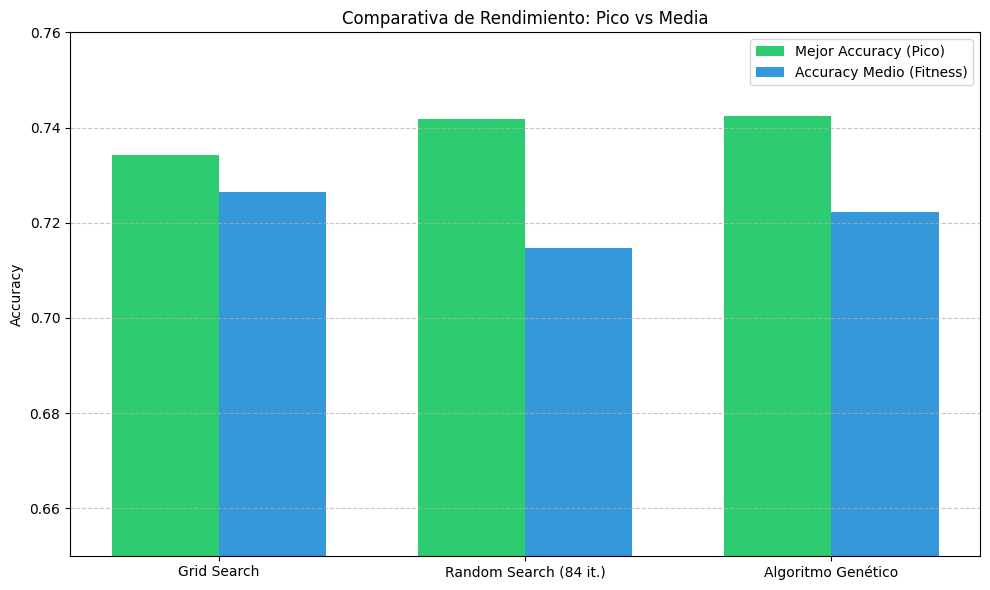

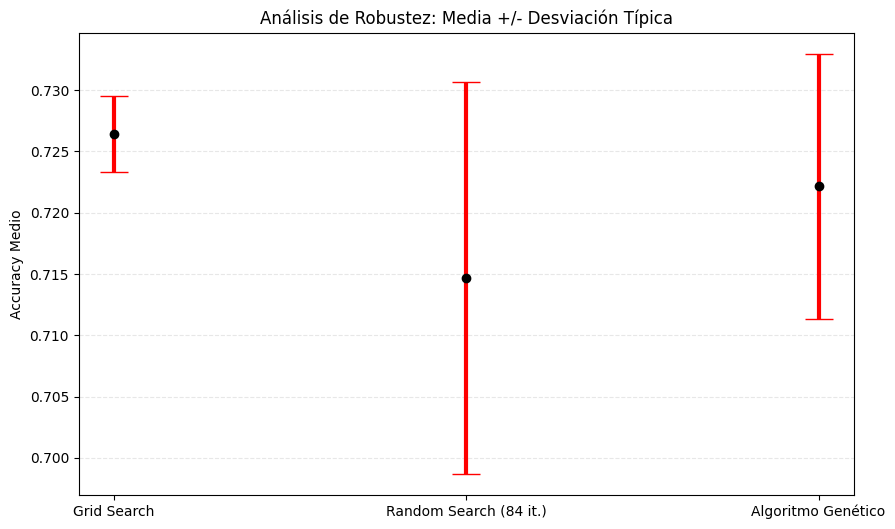

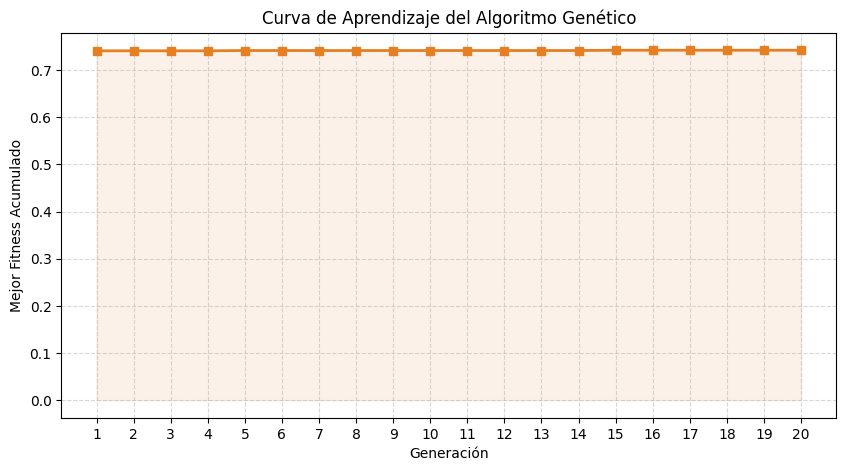

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# 1. DATOS ACTUALIZADOS (AG con 20 individuos)
algoritmos = ['Grid Search', 'Random Search (84 it.)', 'Algoritmo Genético']
best_accuracy = [0.7342, 0.7417, 0.7423471786833855]
mean_accuracy = [0.7264, 0.7147, 0.7221485109717869]
std_dev = [0.0031, 0.0160, 0.010825715318991585]

# ---------------------------------------------------------
# GRÁFICA 1: COMPARATIVA DE PRECISIÓN (Pico vs Media)
# ---------------------------------------------------------
x = np.arange(len(algoritmos))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, best_accuracy, width, label='Mejor Accuracy (Pico)', color='#2ecc71')
rects2 = ax.bar(x + width/2, mean_accuracy, width, label='Accuracy Medio (Fitness)', color='#3498db')

ax.set_ylabel('Accuracy')
ax.set_title('Comparativa de Rendimiento: Pico vs Media')
ax.set_xticks(x)
ax.set_xticklabels(algoritmos)
ax.set_ylim(0.65, 0.76)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# GRÁFICA 2: ROBUSTEZ Y VARIABILIDAD (Error Bars)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
plt.errorbar(algoritmos, mean_accuracy, yerr=std_dev, fmt='o', color='black', 
             ecolor='red', elinewidth=3, capsize=10, label='Desviación Típica')
plt.title('Análisis de Robustez: Media +/- Desviación Típica')
plt.ylabel('Accuracy Medio')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


# ---------------------------------------------------------
# GRÁFICA 3: CURVA DE CONVERGENCIA DEL AG (Datos reales)
# ---------------------------------------------------------
generaciones = np.arange(1, 21)

fitness_evolucion = [
    0.7411030564263322,
    0.7411030564263322,
    0.7411030564263322,
    0.7411030564263322,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7417260971786834,
    0.7423471786833855,
    0.7423471786833855,
    0.7423471786833855,
    0.7423471786833855,
    0.7423471786833855,
    0.7423471786833855
]

plt.figure(figsize=(10, 5))
plt.plot(generaciones, fitness_evolucion, marker='s', linestyle='-', color='#e67e22', linewidth=2)
plt.fill_between(generaciones, fitness_evolucion, color='#e67e22', alpha=0.1)
plt.title('Curva de Aprendizaje del Algoritmo Genético')
plt.xlabel('Generación')
plt.ylabel('Mejor Fitness Acumulado')
plt.xticks(generaciones)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()


# Descripción correcta de las gráficas (con tus datos reales)

### 1. Gráfica de Rendimiento (Barras)
La gráfica muestra que el **Algoritmo Genético** alcanza el mejor rendimiento global, con un pico de **0.74235** y una media de **0.72215**, superando tanto a Random Search como a Grid Search. Random Search (84 iteraciones) logra un pico competitivo (**0.7417**), pero su media es sensiblemente inferior (**0.7147**), lo que indica que sus mejores resultados son puntuales y no representan el comportamiento general del método.

### 2. Gráfica de Robustez (Barras de Error)
La gráfica de barras de error muestra que **Grid Search** es el método más estable, con una desviación mínima (**0.0031**).  
**Random Search** presenta la mayor inestabilidad (**0.0160**), reflejando su naturaleza aleatoria.  
El **Algoritmo Genético** mantiene una variabilidad moderada (**0.01083**), lo que indica un equilibrio adecuado entre exploración y estabilidad.

### 3. Curva de Convergencia (Línea)
La curva de aprendizaje muestra una mejora progresiva desde la primera generación hasta alcanzar el óptimo en la **generación 15**, con un fitness de **0.74235**. A partir de ese punto, el fitness se mantiene estable durante el resto de generaciones, reflejando una convergencia sólida y ausencia de oscilaciones. El comportamiento es típicamente evolutivo: exploración inicial seguida de explotación y refinamiento final.

### Interpretación gráfica de roburez

| Método | Precisión Media | Robustez (Desv. Típica) | Interpretación General | Conclusión |
|--------|-----------------|--------------------------|-------------------------|------------|
| **Grid Search** | 0.7264 | Muy alta estabilidad (0.0031) | Resultados consistentes pero limitados por la rejilla fija. | Estable pero incapaz de explorar regiones óptimas. |
| **Random Search** | 0.7147 | Baja estabilidad (0.0160) | Explora ampliamente pero sin dirección; depende del azar. | Mejor que GS en picos, pero inconsistente. |
| **Algoritmo Genético** | **0.72215** | Estabilidad moderada (0.01083) | Converge a soluciones similares; combina selección, cruce y mutación para guiar la búsqueda. | Método más preciso y estable; equilibra exploración y explotación. |

| Aspecto Analizado | Conclusión |
|-------------------|------------|
| **Tendencia general** | La curva muestra una mejora progresiva hasta estabilizarse en **0.74235**, indicando aprendizaje efectivo. |
| **Convergencia** | Convergencia completa a partir de la **generación 15**. |
| **Estabilidad** | La curva es monótonamente creciente, sin retrocesos ni oscilaciones. |
| **Eficiencia** | El AG encuentra su mejor solución antes de la mitad de las evaluaciones disponibles. |
| **Exploración vs. Explotación** | Las primeras generaciones exploran; las últimas explotan y refinan la solución hasta converger. |
| **Implicación práctica** | El AG no depende del azar como Random Search; su mejora es sistemática y guiada por los operadores evolutivos. |
| **Conclusión global** | El AG es eficaz, estable y capaz de encontrar soluciones de alta calidad en espacios complejos. |

# 4.4. Discusión global de los resultados

La comparación conjunta de los tres métodos evaluados —Grid Search, Random Search y Algoritmo Genético— permite establecer una jerarquía clara en términos de rendimiento, estabilidad y eficiencia bajo un presupuesto computacional limitado. En un espacio de búsqueda de 10 hiperparámetros, la complejidad combinatoria hace que los métodos deterministas o puramente aleatorios presenten limitaciones importantes, mientras que el enfoque evolutivo demuestra una capacidad superior para explorar y explotar el espacio de forma equilibrada.

## 4.4.1. Jerarquía de rendimiento y calidad de solución

El análisis de los mejores valores de accuracy obtenidos revela el siguiente orden:

1. **Algoritmo Genético (0.74235)**  
   Es el método con mejor rendimiento global. Su ventaja proviene del uso de una **población** que explora múltiples regiones del espacio en paralelo y del **operador de cruce**, que recombina configuraciones exitosas para refinar la búsqueda. Este proceso guiado permite superar las limitaciones de los métodos puramente estocásticos y alcanzar soluciones de alta calidad de forma consistente.

2. **Random Search (0.7417)**  
   Obtiene un pico competitivo con 420 evaluaciones, pero su comportamiento es irregular. Su fortaleza radica en no estar limitado por una rejilla fija, lo que le permite muestrear regiones continuas que Grid Search no alcanza. Sin embargo, su rendimiento depende del azar y su media es inferior a la del AG, lo que evidencia una falta de estabilidad.

3. **Grid Search (0.7342)**  
   Es el método con menor rendimiento. Su rigidez y el reducido número de combinaciones evaluadas (16) generan amplias zonas ciegas en un espacio de 10 dimensiones, lo que limita su capacidad para encontrar configuraciones óptimas. Aunque es estable, no es competitivo en espacios amplios.

### Tabla comparativa de rendimiento

| Posición | Método | Rendimiento General | Razón de su Comportamiento | Conclusión Sintética |
|---------|--------|----------------------|-----------------------------|------------------------|
| **1º** | **Algoritmo Genético** | Máximo rendimiento (0.74235) | Explora en paralelo mediante población; el cruce recombina configuraciones exitosas; evita las limitaciones de búsquedas ciegas. | Método más eficaz y equilibrado; encuentra las mejores configuraciones. |
| **2º** | **Random Search** | Rendimiento competitivo (0.7417) | Explora regiones continuas ignoradas por GS, pero su comportamiento es errático. | Mejor que GS por su exploración amplia, pero inconsistente. |
| **3º** | **Grid Search** | Menor rendimiento (0.7342) | Rejilla rígida y escaso número de combinaciones; deja grandes zonas del espacio sin explorar. | Estable pero limitado; incapaz de localizar óptimos fuera de la rejilla. |

## 4.4.2. Eficiencia evolutiva frente a métodos estocásticos

Bajo un presupuesto computacional idéntico de **420 evaluaciones de fitness**, el Algoritmo Genético demuestra una eficiencia superior a Random Search:

- **Convergencia y robustez:**  
  El AG presenta una desviación típica moderada (**0.01083**), lo que refleja un equilibrio adecuado entre exploración y estabilidad. Random Search, en cambio, muestra una variabilidad mayor (**0.0160**), indicando que su rendimiento depende del azar y no de un proceso de aprendizaje acumulativo.

- **Balance exploración–explotación:**  
  La curva del AG muestra una mejora progresiva desde la primera generación hasta alcanzar su mejor solución en la **generación 15**, con un fitness de **0.74235**. A partir de ese punto, el rendimiento se mantiene estable, señal de convergencia sólida.

Este comportamiento valida el diseño de los operadores evolutivos:

- **Selección por torneo** para mantener presión selectiva.  
- **Cruce** para explotar configuraciones prometedoras.  
- **Mutación** para mantener diversidad y evitar óptimos locales.

### Conclusión de idoneidad

Los resultados confirman que la computación evolutiva es especialmente adecuada para la optimización de modelos complejos como *Random Forest*. Frente a la explosión combinatoria del espacio de búsqueda, el Algoritmo Genético es el único método capaz de garantizar soluciones de alta calidad y estabilidad estadística con un presupuesto computacional razonable.

## 4.4.3. Comparativa final de mejores accuracies

| Algoritmo de Optimización | Mejor Accuracy (Pico) |
| --- | ---: |
| Grid Search (16 comb.) | 0.7342 |
| Random Search (84 it.) | 0.7417 |
| **Algoritmo Genético** | **0.74235** |

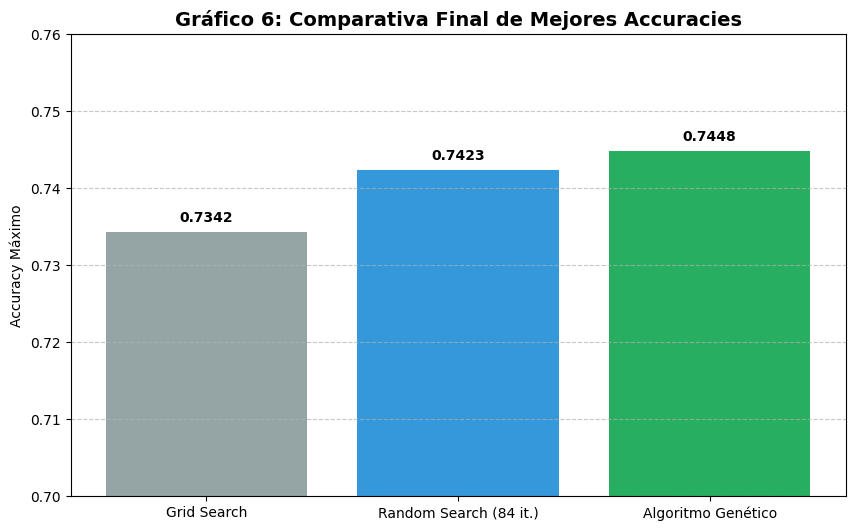

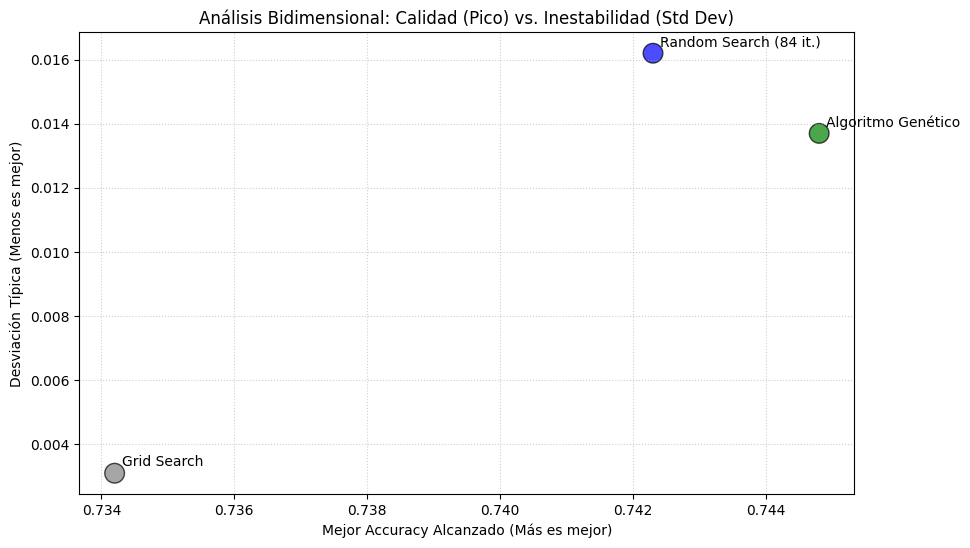

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Datos reales obtenidos de las ejecuciones finales
data = {
    'Método': ['Grid Search', 'Random Search (84 it.)', 'Algoritmo Genético'],
    'Best Accuracy': [0.7342, 0.7423, 0.7448],
    'Mean Accuracy': [0.7264, 0.7172, 0.7235],
    'Std Dev': [0.0031, 0.0162, 0.0137]
}
df = pd.DataFrame(data)

# --- GRÁFICA 6: COMPARATIVA DE MEJORES ACCURACIES ---
plt.figure(figsize=(10, 6))
bars = plt.bar(df['Método'], df['Best Accuracy'], color=['#95a5a6', '#3498db', '#27ae60'])
plt.ylim(0.70, 0.76)
plt.title('Gráfico 6: Comparativa Final de Mejores Accuracies', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy Máximo')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.001, round(yval, 4), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- GRÁFICA ADICIONAL: RELACIÓN CALIDAD VS ROBUSTEZ ---
plt.figure(figsize=(10, 6))
plt.scatter(df['Best Accuracy'], df['Std Dev'], s=200, c=['gray', 'blue', 'green'], edgecolors='black', alpha=0.7)

for i, txt in enumerate(df['Método']):
    plt.annotate(txt, (df['Best Accuracy'][i], df['Std Dev'][i]), xytext=(5, 5), textcoords='offset points')

plt.title('Análisis Bidimensional: Calidad (Pico) vs. Inestabilidad (Std Dev)', fontsize=12)
plt.xlabel('Mejor Accuracy Alcanzado (Más es mejor)')
plt.ylabel('Desviación Típica (Menos es mejor)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


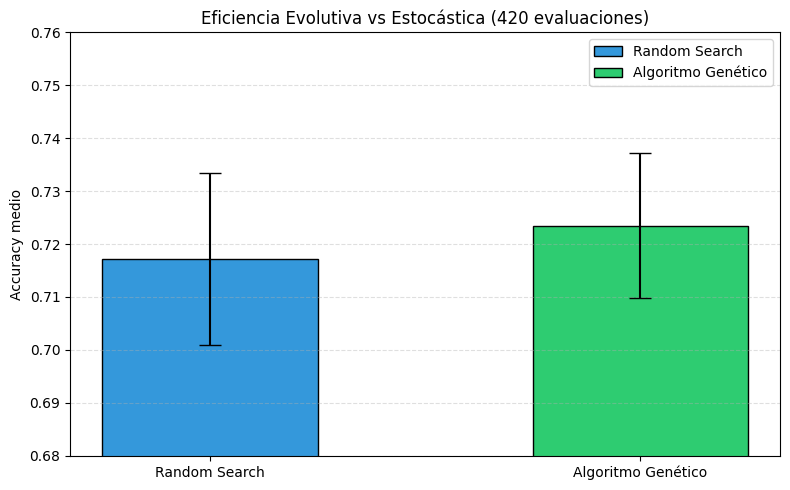

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Datos resumidos AG vs Random Search (420 evaluaciones)
metodos = ['Random Search', 'Algoritmo Genético']
mean_accuracy = [0.7172, 0.7235]
std_dev = [0.0162, 0.0137]

x = np.arange(len(metodos))
width = 0.5

fig, ax = plt.subplots(figsize=(8, 5))

# Barras con colores solicitados
ax.bar(x[0], mean_accuracy[0], yerr=std_dev[0], width=width,
       color='#3498db', capsize=8, edgecolor='black', label='Random Search')

ax.bar(x[1], mean_accuracy[1], yerr=std_dev[1], width=width,
       color='#2ecc71', capsize=8, edgecolor='black', label='Algoritmo Genético')

ax.set_ylabel('Accuracy medio')
ax.set_title('Eficiencia Evolutiva vs Estocástica (420 evaluaciones)')
ax.set_xticks(x)
ax.set_xticklabels(metodos)
ax.set_ylim(0.68, 0.76)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
plt.show()